## Imports & Project Setup

In [1]:
import random
from pathlib import Path
from typing import Tuple, Optional
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torchvision.utils import save_image

from skimage.color import rgb2lab, lab2rgb
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Create project folders
ROOT = Path("./colorization_gan")
DATA_DIR = ROOT / "data"
SAMPLES_DIR = ROOT / "samples"
CKPT_DIR = ROOT / "checkpoints"

for folder in [DATA_DIR, SAMPLES_DIR, CKPT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders ready!")
print(f"Samples will be saved to: {SAMPLES_DIR}")
print(f"Checkpoints will be saved to: {CKPT_DIR}")

Project folders ready!
Samples will be saved to: colorization_gan/samples
Checkpoints will be saved to: colorization_gan/checkpoints


## Configuration

In [2]:
class Config:
    """All hyperparameters in one place – easy to change!"""

    IMAGE_SIZE: int = 32
    BATCH_SIZE: int = 64
    NUM_EPOCHS: int = 50
    LR: float = 2e-4
    BETA1: float = 0.5
    L1_WEIGHT: float = 100.0

    GRAYSCALE_CHANNELS: int = 1
    COLOR_CHANNELS_AB: int = 2

    LOG_INTERVAL: int = 200
    SAMPLE_EVERY: int = 5
    SAVE_CKPT_EVERY: int = 10

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


cfg = Config()

get_timestamp = lambda: datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"Using device: {cfg.DEVICE}")
print(f"Will train for {cfg.NUM_EPOCHS} epochs")

Using device: cpu
Will train for 50 epochs


## Color Space Conversion (RGB to Lab to RGB)

In [3]:
def rgb_to_lab_batch(rgb: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Converts a batch of RGB images (range [-1, 1]) to Lab color space.
    We only give the L (brightness) to the model and ask it to predict ab (color).
    """
    # Bring to CPU and convert from [-1,1] to [0,1]
    rgb_np = ((rgb.cpu().permute(0, 2, 3, 1).numpy() + 1.0) / 2.0).clip(0, 1)

    L_list = []
    ab_list = []
    for img in rgb_np:
        lab = rgb2lab(img)
        L_list.append(lab[:, :, 0])  # Luminance only
        ab_list.append(lab[:, :, 1:])  # Color channels

    L = torch.tensor(np.array(L_list), dtype=torch.float32).unsqueeze(1).to(cfg.DEVICE)
    ab = (
        torch.tensor(np.array(ab_list), dtype=torch.float32)
        .permute(0, 3, 1, 2)
        .to(cfg.DEVICE)
    )

    # Normalize to [-1, 1] so Tanh output matches perfectly
    return (L / 50.0) - 1.0, ab / 110.0


def lab_to_rgb_batch(L: torch.Tensor, ab: torch.Tensor) -> torch.Tensor:
    """Converts predicted L + ab back to RGB for display."""
    L_scaled = (L + 1.0) * 50.0
    ab_scaled = ab * 110.0
    lab = torch.cat([L_scaled, ab_scaled], dim=1)

    lab_np = lab.permute(0, 2, 3, 1).cpu().numpy()
    lab_np = np.clip(lab_np, [0, -128, -128], [100, 127, 127])  # Prevent invalid colors

    rgb_list = [lab2rgb(img, illuminant="D65") for img in lab_np]
    rgb_tensor = torch.tensor(np.stack(rgb_list), dtype=torch.float32)
    return rgb_tensor.permute(0, 3, 1, 2).to(cfg.DEVICE).clamp(0, 1)

## Generator (U-Net)

In [4]:
class ColorizationGenerator(nn.Module):
    """
    U-Net generator: takes grayscale image (L channel) and outputs color (ab channels).
    Skip connections preserve fine details like edges and textures.
    """

    def __init__(self) -> None:
        super().__init__()

        # Encoder – compress image
        self.down1 = nn.Conv2d(1, 64, 4, 2, 1, bias=False)
        self.down2 = nn.Conv2d(64, 128, 4, 2, 1, bias=False)
        self.down3 = nn.Conv2d(128, 256, 4, 2, 1, bias=False)
        self.down4 = nn.Conv2d(256, 512, 4, 2, 1, bias=False)

        # Decoder – expand + skip connections
        self.up1 = nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False)
        self.up2 = nn.ConvTranspose2d(512, 128, 4, 2, 1, bias=False)
        self.up3 = nn.ConvTranspose2d(256, 64, 4, 2, 1, bias=False)
        self.final = nn.ConvTranspose2d(128, 2, 4, 2, 1)

        self.bn_up1 = nn.BatchNorm2d(256)
        self.bn_up2 = nn.BatchNorm2d(128)
        self.bn_up3 = nn.BatchNorm2d(64)

        self.act = nn.LeakyReLU(0.2, inplace=True)
        self.out = nn.Tanh()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        d1 = self.act(self.down1(x))
        d2 = self.act(self.down2(d1))
        d3 = self.act(self.down3(d2))
        d4 = self.act(self.down4(d3))

        u1 = self.act(self.bn_up1(self.up1(d4)))
        u2 = self.act(self.bn_up2(self.up2(torch.cat([u1, d3], 1))))
        u3 = self.act(self.bn_up3(self.up3(torch.cat([u2, d2], 1))))
        return self.out(self.final(torch.cat([u3, d1], 1)))

## Discriminator (PatchGAN)

In [5]:
class ColorizationDiscriminator(nn.Module):
    """
    PatchGAN: judges small patches instead of the whole image.
    Gives sharper, more detailed feedback to the generator.
    """

    def __init__(self) -> None:
        super().__init__()

        def conv_block(in_c: int, out_c: int, norm: bool = True, stride: int = 2):
            layers = [nn.Conv2d(in_c, out_c, 4, stride=stride, padding=1)]
            if norm:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return nn.Sequential(*layers)

        self.net = nn.Sequential(
            conv_block(3, 64, norm=False),
            conv_block(64, 128),
            conv_block(128, 256),
            conv_block(256, 512, stride=1),
            nn.Conv2d(512, 1, 4, 1, 1),
        )

    def forward(self, L: torch.Tensor, ab: torch.Tensor) -> torch.Tensor:
        x = torch.cat([L, ab], dim=1)
        return self.net(x)

## Dataset

In [6]:
transform = transforms.Compose(
    [
        transforms.Resize(cfg.IMAGE_SIZE),
        transforms.CenterCrop(cfg.IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.5] * 3, [0.5] * 3),
    ]
)

train_dataset = datasets.CIFAR10(
    root=DATA_DIR, train=True, download=True, transform=transform
)
train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True,
)

print(f"Loaded {len(train_dataset)} training images")

Loaded 50000 training images


## Models & Resume Logic

In [7]:
generator = ColorizationGenerator().to(cfg.DEVICE)
discriminator = ColorizationDiscriminator().to(cfg.DEVICE)

criterion_gan = nn.MSELoss()
criterion_l1 = nn.L1Loss()

optimizer_G = optim.Adam(generator.parameters(), lr=cfg.LR, betas=(cfg.BETA1, 0.999))
optimizer_D = optim.Adam(
    discriminator.parameters(), lr=cfg.LR, betas=(cfg.BETA1, 0.999)
)

# Find latest checkpoint
ckpts = sorted(CKPT_DIR.glob("generator_epoch_*.pth"))
start_epoch = 0
skip_training = False  # Flag to skip training loop

if ckpts:
    latest = ckpts[-1]
    parts = latest.stem.split("_")
    epoch_num = int(parts[2])
    ts_part = "_".join(parts[3:])

    print(f"Found checkpoint from epoch {epoch_num}")

    # Always load the latest model
    generator.load_state_dict(torch.load(latest, map_location=cfg.DEVICE))
    disc_path = CKPT_DIR / f"discriminator_epoch_{epoch_num}_{ts_part}.pth"
    if disc_path.exists():
        discriminator.load_state_dict(torch.load(disc_path, map_location=cfg.DEVICE))

    opt_g_path = CKPT_DIR / f"optimizer_G_epoch_{epoch_num}_{ts_part}.pth"
    if opt_g_path.exists():
        optimizer_G.load_state_dict(torch.load(opt_g_path, map_location=cfg.DEVICE))
        optimizer_D.load_state_dict(
            torch.load(CKPT_DIR / f"optimizer_D_epoch_{epoch_num}_{ts_part}.pth")
        )

    # Model is fully trained?
    if epoch_num >= cfg.NUM_EPOCHS:
        print(f"\nModel is fully trained ({epoch_num} >= {cfg.NUM_EPOCHS} epochs)!")
        response = input("Load model for inference only? (Y/n): ").strip().lower()

        if response in {"", "y", "yes"}:
            print("Model loaded for inference only. Skipping training.")
            skip_training = True
            start_epoch = cfg.NUM_EPOCHS + 1  # Ensures training loop is skipped
        else:
            # Continue training to a higher epoch
            while True:
                try:
                    new_target = input(
                        f"Enter new total epochs (current: {cfg.NUM_EPOCHS}, press Enter to keep): "
                    ).strip()
                    if not new_target:
                        print("Keeping current target epochs.")
                        start_epoch = epoch_num + 1
                        break
                    new_target = int(new_target)
                    if new_target > cfg.NUM_EPOCHS:
                        cfg.NUM_EPOCHS = new_target
                        print(f"Continuing training to epoch {cfg.NUM_EPOCHS}...")
                        start_epoch = epoch_num + 1
                        break
                    else:
                        print("Please enter a number greater than current epochs.")
                except ValueError:
                    print("Please enter a valid number.")
    else:
        start_epoch = epoch_num + 1
        print(f"Resuming training from epoch {start_epoch}")
else:
    print("No checkpoint found → starting from scratch")

print(f"Training range: {start_epoch} → {cfg.NUM_EPOCHS}")

Found checkpoint from epoch 50

Model is fully trained (50 >= 50 epochs)!


Load model for inference only? (Y/n):  


Model loaded for inference only. Skipping training.
Training range: 51 → 50


## Training Loop

In [8]:
run_ts = get_timestamp()
print(
    f"Training has begun! We'll get a sample every {cfg.SAMPLE_EVERY}, "
    f"and save a checkpoint every {cfg.SAVE_CKPT_EVERY}.\n"
)

for epoch in range(start_epoch, cfg.NUM_EPOCHS + 1):
    print(f"Epoch {epoch}/{cfg.NUM_EPOCHS}")
    prog = tqdm(train_loader, desc=f"Epoch {epoch:>3}")

    for imgs, _ in prog:
        imgs = imgs.to(cfg.DEVICE, non_blocking=True)
        L, real_ab = rgb_to_lab_batch(imgs)

        # Train Discriminator
        optimizer_D.zero_grad()
        real_pred = discriminator(L, real_ab)
        fake_ab = generator(L)
        fake_pred = discriminator(L, fake_ab.detach())
        loss_D = (
            criterion_gan(real_pred, torch.ones_like(real_pred))
            + criterion_gan(fake_pred, torch.zeros_like(fake_pred))
        ) / 2
        loss_D.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()
        fake_pred = discriminator(L, fake_ab)
        loss_G_adv = criterion_gan(fake_pred, torch.ones_like(fake_pred))
        loss_G_l1 = criterion_l1(fake_ab, real_ab) * cfg.L1_WEIGHT
        loss_G = loss_G_adv + loss_G_l1
        loss_G.backward()
        optimizer_G.step()

        prog.set_postfix({"D": f"{loss_D.item():.4f}", "G": f"{loss_G.item():.3f}"})

    # Save sample every epoch
    if epoch % cfg.SAMPLE_EVERY == 0:
        with torch.no_grad():
            colored = lab_to_rgb_batch(L[:12], generator(L[:12]))
            gray = (L[:12].repeat(1, 3, 1, 1) * 0.5 + 0.5).clamp(0, 1)
            real = (imgs[:12] * 0.5 + 0.5).clamp(0, 1)
            grid = torch.cat([gray, colored, real], dim=0)
            save_image(grid, SAMPLES_DIR / f"epoch_{epoch:03d}_{run_ts}.png", nrow=12)

    # Save checkpoint only from epoch 10 onward
    save_this_epoch = (
        epoch % cfg.SAVE_CKPT_EVERY == 0 and epoch >= cfg.SAVE_CKPT_EVERY
    ) or epoch == cfg.NUM_EPOCHS
    if save_this_epoch:
        suffix = f"epoch_{epoch}_{run_ts}.pth"
        torch.save(generator.state_dict(), CKPT_DIR / f"generator_{suffix}")
        torch.save(discriminator.state_dict(), CKPT_DIR / f"discriminator_{suffix}")
        torch.save(optimizer_G.state_dict(), CKPT_DIR / f"optimizer_G_{suffix}")
        torch.save(optimizer_D.state_dict(), CKPT_DIR / f"optimizer_D_{suffix}")
        print(f"Checkpoint saved: {suffix}")

print("\nTraining finished!")

Training has begun! We'll get a sample every 5, and save a checkpoint every 10.


Training finished!


## Side-by-Side GAN Colorization Result


Colorizing image — please wait...

Saved: RESULT_RANDOM_20251210_170703.png


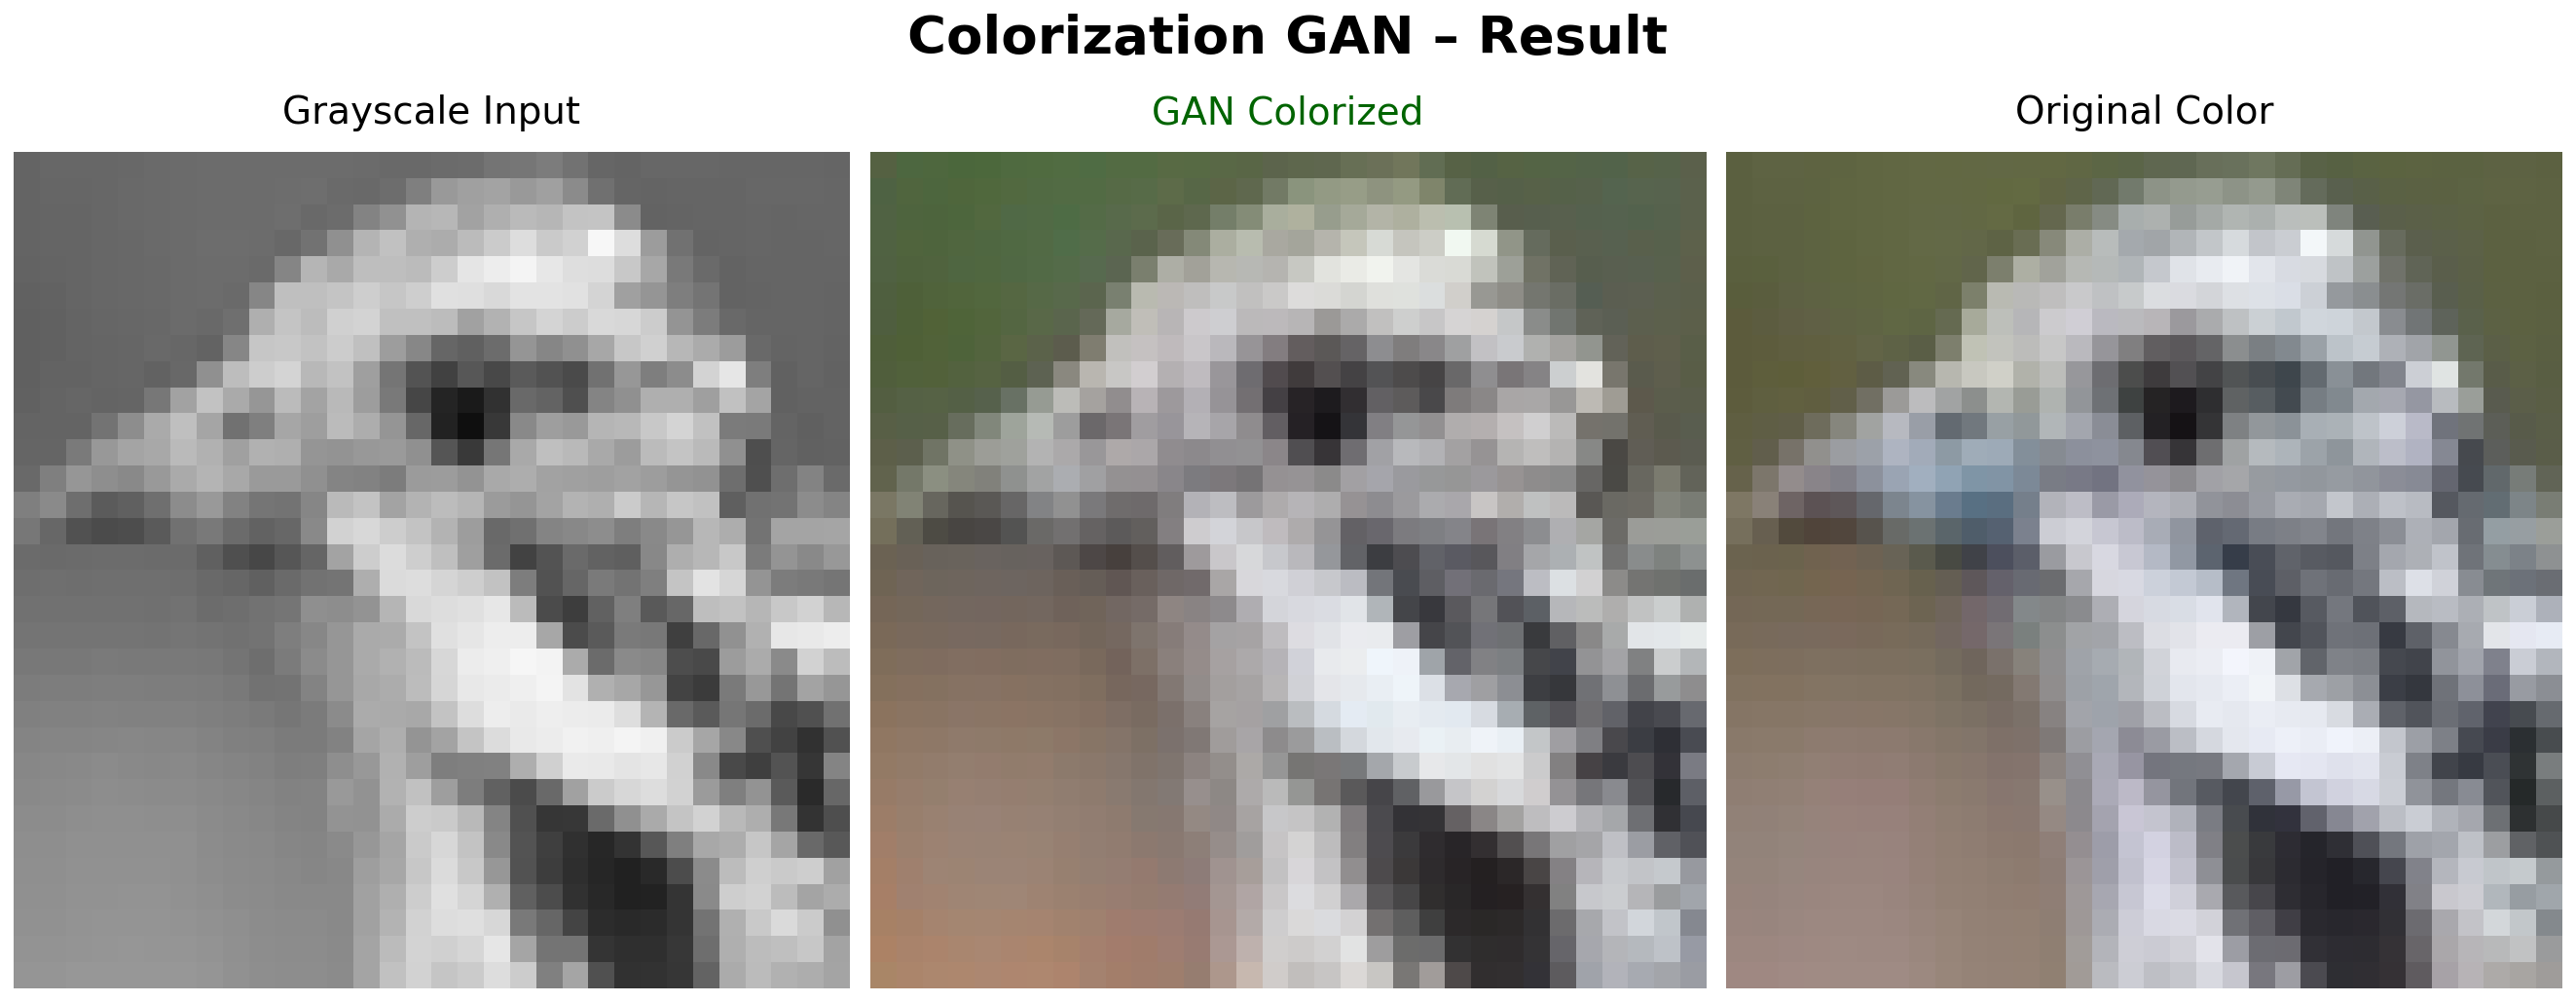

In [13]:
def show_colorization(image_path: Optional[str] = None) -> None:
    """
    Colorizes a single image and shows a beautiful side-by-side comparison.

    Args:
        image_path (str, optional): Path to your own 32×32 RGB image.
            If None → picks a random image from CIFAR-10.
    """
    print("\nColorizing image — please wait...\n")
    generator.eval()

    with torch.no_grad():
        if image_path:
            try:
                pil_img = Image.open(image_path).convert("RGB")
                # Apply same preprocessing as during training
                preprocess = transforms.Compose(
                    [
                        transforms.Resize(cfg.IMAGE_SIZE),
                        transforms.CenterCrop(cfg.IMAGE_SIZE),
                        transforms.ToTensor(),
                        transforms.Normalize([0.5] * 3, [0.5] * 3),  # → [-1, 1]
                    ]
                )
                img_tensor = preprocess(pil_img).unsqueeze(0).to(cfg.DEVICE)
                print(f"Loaded your image: {Path(image_path).name}")
            except Exception as e:
                print(f"Error loading image: {e}")
                print("Falling back to random CIFAR-10 image...")
                image_path = None

        if image_path is None:
            idx = random.randint(0, len(train_dataset) - 1)
            img, _ = train_dataset[idx]
            img_tensor = img.unsqueeze(0).to(cfg.DEVICE)

        # Forward pass
        L, _ = rgb_to_lab_batch(img_tensor)
        fake_ab = generator(L)
        colored = lab_to_rgb_batch(L, fake_ab)

        # Convert to [0,1] and move to CPU for display
        gray = (L.cpu() * 0.5 + 0.5).repeat(1, 3, 1, 1).cpu().squeeze(0)
        pred = colored.cpu().squeeze(0)
        real = (img_tensor * 0.5 + 0.5).cpu().squeeze(0)

        # To numpy (H, W, C)
        gray_np = gray.permute(1, 2, 0).numpy()
        pred_np = pred.permute(1, 2, 0).numpy()
        real_np = real.permute(1, 2, 0).numpy()

        plt.figure(figsize=(19, 8), dpi=140, facecolor="white")
        plt.suptitle(
            "Colorization GAN – Result", fontsize=28, fontweight="bold", y=0.96
        )

        plt.subplot(1, 3, 1)
        plt.imshow(gray_np, cmap="gray")
        plt.title("Grayscale Input", fontsize=20, pad=15)
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(pred_np)
        plt.title("GAN Colorized", fontsize=20, pad=15, color="darkgreen")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(real_np)
        plt.title("Original Color", fontsize=20, pad=15)
        plt.axis("off")

        plt.tight_layout()
        plt.subplots_adjust(top=0.88)

        save_name = (
            f"RESULT_{'CUSTOM' if image_path else 'RANDOM'}_{get_timestamp()}.png"
        )
        save_path = SAMPLES_DIR / save_name
        plt.savefig(save_path, bbox_inches="tight", dpi=300, facecolor="white")
        print(f"Saved: {save_name}")

        plt.show()


show_colorization()  # Random CIFAR-10 image
# show_colorization("my_photo_32x32.png")  # Your own 32×32 image